In [9]:
import pandas as pd
import numpy as np
wine = pd.read_csv('winequality-white.csv',sep=';')
wine.columns = wine.columns.str.replace(' ', '_')

In [10]:
from sklearn.model_selection import train_test_split
X = wine.drop(['quality'], axis=1)
y = wine.quality
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3, 
                                                    random_state=1031)

In [13]:
wine_train = X_train.copy()
wine_train['quality'] = y_train
wine_train.corr().round(2)
wine_train.corr()
# wine_train.corr().round(2)['quality'] # to see only relevant predictors
# wine_train.corr().round(2).drop('quality', axis = 1) # to see only relevant predictors

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
fixed_acidity,1.000000,-0.008035,0.290960,0.083030,0.020008,-0.050687,0.100379,0.265394,-0.423876,-0.001418,-0.119222,-0.119303
volatile_acidity,-0.008035,1.000000,-0.148798,0.053450,0.067359,-0.108093,0.079176,0.012759,-0.040307,-0.043045,0.066274,-0.189190
citric_acid,0.290960,-0.148798,1.000000,0.105630,0.132425,0.092577,0.129862,0.157538,-0.169070,0.061537,-0.078032,-0.019300
residual_sugar,0.083030,0.053450,0.105630,1.000000,0.073221,0.303909,0.411905,0.834950,-0.192159,-0.021933,-0.457953,-0.094536
chlorides,0.020008,0.067359,0.132425,0.073221,1.000000,0.085683,0.178432,0.243215,-0.089734,0.006207,-0.347618,-0.197412
free_sulfur_dioxide,-0.050687,-0.108093,0.092577,0.303909,0.085683,1.000000,0.622588,0.301199,-0.002246,0.078794,-0.241526,0.017594
total_sulfur_dioxide,0.100379,0.079176,0.129862,0.411905,0.178432,0.622588,1.000000,0.543446,0.003590,0.146633,-0.442693,-0.159768
density,0.265394,0.012759,0.157538,0.834950,0.243215,0.301199,0.543446,1.000000,-0.090698,0.074501,-0.798872,-0.305161
pH,-0.423876,-0.040307,-0.169070,-0.192159,-0.089734,-0.002246,0.003590,-0.090698,1.000000,0.148123,0.117975,0.108187
sulphates,-0.001418,-0.043045,0.061537,-0.021933,0.006207,0.078794,0.146633,0.074501,0.148123,1.000000,-0.011193,0.063209


In [14]:
wine_train.corr().quality.round(2)

fixed_acidity          -0.12
volatile_acidity       -0.19
citric_acid            -0.02
residual_sugar         -0.09
chlorides              -0.20
free_sulfur_dioxide     0.02
total_sulfur_dioxide   -0.16
density                -0.31
pH                      0.11
sulphates               0.06
alcohol                 0.43
quality                 1.00
Name: quality, dtype: float64

In [8]:
wine.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [16]:
(
    wine_train
        .corr()
        .quality
        .round(2)
        .sort_values(ascending = False)
)

quality                 1.00
alcohol                 0.43
pH                      0.11
sulphates               0.06
free_sulfur_dioxide     0.02
citric_acid            -0.02
residual_sugar         -0.09
fixed_acidity          -0.12
total_sulfur_dioxide   -0.16
volatile_acidity       -0.19
chlorides              -0.20
density                -0.31
Name: quality, dtype: float64

In [19]:
(
    wine_train
        .corr()
        .drop(columns = 'quality', axis = 1)
        .round(2)
#        .sort_values(ascending = False)
)

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
fixed_acidity,1.00,-0.01,0.29,0.08,0.02,-0.05,0.10,0.27,-0.42,-0.00,-0.12
volatile_acidity,-0.01,1.00,-0.15,0.05,0.07,-0.11,0.08,0.01,-0.04,-0.04,0.07
citric_acid,0.29,-0.15,1.00,0.11,0.13,0.09,0.13,0.16,-0.17,0.06,-0.08
residual_sugar,0.08,0.05,0.11,1.00,0.07,0.30,0.41,0.83,-0.19,-0.02,-0.46
chlorides,0.02,0.07,0.13,0.07,1.00,0.09,0.18,0.24,-0.09,0.01,-0.35
free_sulfur_dioxide,-0.05,-0.11,0.09,0.30,0.09,1.00,0.62,0.30,-0.00,0.08,-0.24
total_sulfur_dioxide,0.10,0.08,0.13,0.41,0.18,0.62,1.00,0.54,0.00,0.15,-0.44
density,0.27,0.01,0.16,0.83,0.24,0.30,0.54,1.00,-0.09,0.07,-0.80
pH,-0.42,-0.04,-0.17,-0.19,-0.09,-0.00,0.00,-0.09,1.00,0.15,0.12
sulphates,-0.00,-0.04,0.06,-0.02,0.01,0.08,0.15,0.07,0.15,1.00,-0.01


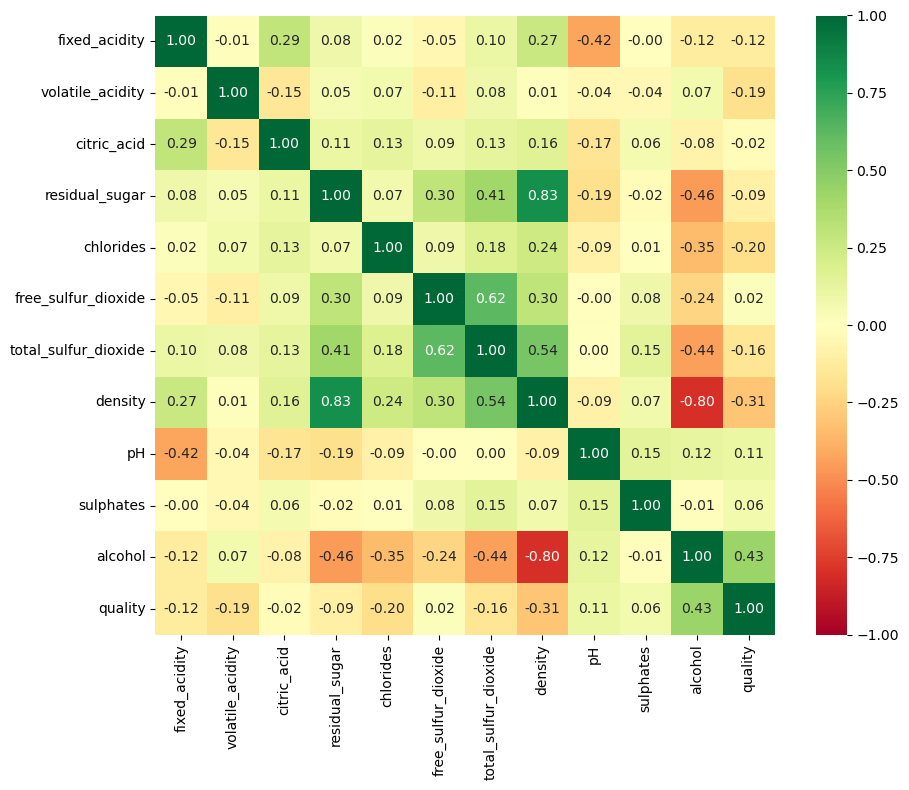

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(wine_train.corr(), 
            annot=True, 
            fmt=".2f", 
            cmap="RdYlGn",
            vmin=-1, 
            vmax=1, 
            square=True)
plt.tight_layout()
plt.show()

In [23]:
from statsmodels.formula.api import ols
reg = ols('quality~fixed_acidity + volatile_acidity + citric_acid + residual_sugar + chlorides + free_sulfur_dioxide + total_sulfur_dioxide + density + pH + sulphates + alcohol',
    data=wine_train)
reg.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.277
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     118.7
Date:                Thu, 06 Nov 2025   Prob (F-statistic):          1.33e-230
Time:                        10:53:57   Log-Likelihood:                -3879.7
No. Observations:                3428   AIC:                             7783.
Df Residuals:                    3416   BIC:                             7857.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept              194.0322     27.448      7.069      0.000     140.215     247.849
fixed_acidity            0.1019      0.028      3.654      0.000       0.047       0.157
volatile_acidity        -1.8070      0.136    -13.289      0.000      -2.074      -1.540
citric_acid             -0.0459      0.114     -0.403      0.687      -0.269       0.177
residual_sugar           0.0957      0.010      9.240      0.000       0.075       0.116
chlorides                0.2178      0.642      0.339      0.734      -1.041       1.477
free_sulfur_dioxide      0.0034      0.001      3.433      0.001       0.001       0.005
total_sulfur_dioxide  3.497e-05      0.000      0.076      0.939      -0.001       0.001
density               -194.8589     27.820     -7.004      0.000    -249.405    -140.312
pH                       0.8807      0.136      6.488      0.000       0.615       1.147
sulphates                0.6923      0.122      5.671      0.000       0.453       0.932
alcohol                  0.1387      0.035      3.988      0.000       0.071       0.207
==============================================================================
Omnibus:                       85.730   Durbin-Watson:                   1.942
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              201.350
Skew:                          -0.013   Prob(JB):                     1.89e-44
Kurtosis:                       4.187   Cond. No.                     4.57e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.57e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.api import add_constant
X_with_const = add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                   for i in range(X_with_const.shape[1])]

vif_data.sort_values('VIF',ascending=False)

,feature,VIF
0,const,4.570781e+06
8,density,3.973410e+01
4,residual_sugar,1.629447e+01
11,alcohol,1.093458e+01
1,fixed_acidity,3.277995e+00
9,pH,2.539471e+00
7,total_sulfur_dioxide,2.348395e+00
6,free_sulfur_dioxide,1.826211e+00
5,chlorides,1.239078e+00
3,citric_acid,1.176657e+00


# Forward Selection

In [28]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
sfs = SequentialFeatureSelector(LinearRegression(),
                                  k_features='best',       
                                  forward=True,
                                  floating=False,          
                                  scoring='r2',
                                  cv=5)
sfs = sfs.fit(X_train, y_train)
#pd.DataFrame(sfs.get_metric_dict()).T.loc[:,['feature_names','avg_score']].sort_values('avg_score', ascending = False)

In [30]:
sfs.k_feature_names_

('fixed_acidity',
 'volatile_acidity',
 'residual_sugar',
 'free_sulfur_dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol')

In [34]:
sfs.get_metric_dict()
#When we see braces in this, it means it need to be coverted into dataframe

{1: {'feature_idx': (10,),
  'cv_scores': array([0.21112629, 0.21107068, 0.15191014, 0.18223137, 0.14682803]),
  'avg_score': np.float64(0.1806332998878612),
  'feature_names': ('alcohol',),
  'ci_bound': np.float64(0.03555694635709),
  'std_dev': np.float64(0.027664512262678725),
  'std_err': np.float64(0.013832256131339362)},
 2: {'feature_idx': (1, 10),
  'cv_scores': array([0.24318219, 0.25978523, 0.22296047, 0.23140578, 0.18121408]),
  'avg_score': np.float64(0.22770954880778893),
  'feature_names': ('volatile_acidity', 'alcohol'),
  'ci_bound': np.float64(0.03384147527792536),
  'std_dev': np.float64(0.026329817482389814),
  'std_err': np.float64(0.013164908741194907)},
 3: {'feature_idx': (1, 3, 10),
  'cv_scores': array([0.26138789, 0.28202446, 0.22215701, 0.2583948 , 0.20222263]),
  'avg_score': np.float64(0.24523735724884865),
  'feature_names': ('volatile_acidity', 'residual_sugar', 'alcohol'),
  'ci_bound': np.float64(0.0371189601511016),
  'std_dev': np.float64(0.028879812

In [35]:
pd.DataFrame(sfs.get_metric_dict())

,1,2,3,4,5,6,7,8,9,10,11
feature_idx,"(10,)","(1, 10)","(1, 3, 10)","(1, 3, 5, 10)","(0, 1, 3, 5, 10)","(0, 1, 3, 5, 9, 10)","(0, 1, 3, 5, 7, 9, 10)","(0, 1, 3, 5, 7, 8, 9, 10)","(0, 1, 3, 4, 5, 7, 8, 9, 10)","(0, 1, 2, 3, 4, 5, 7, 8, 9, 10)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)"
cv_scores,"[0.2111262855940188, 0.21107067597073337, 0.15...","[0.24318218771410016, 0.2597852256356995, 0.22...","[0.26138788656531275, 0.28202445919015995, 0.2...","[0.27195000645307377, 0.28161233131749475, 0.2...","[0.2779340902907649, 0.2868657521707305, 0.233...","[0.2758725559601378, 0.2933341612781051, 0.237...","[0.2765012414097604, 0.28525998157903887, 0.24...","[0.28802382095809265, 0.3041198431667208, 0.24...","[0.2878573778801172, 0.3041170206951549, 0.249...","[0.2877861929279224, 0.3024884831442426, 0.249...","[0.28778301179723875, 0.3021649163466775, 0.24..."
avg_score,0.180633,0.22771,0.245237,0.250115,0.253449,0.256356,0.258087,0.267037,0.26688,0.266418,0.265909
feature_names,"(alcohol,)","(volatile_acidity, alcohol)","(volatile_acidity, residual_sugar, alcohol)","(volatile_acidity, residual_sugar, free_sulfur...","(fixed_acidity, volatile_acidity, residual_sug...","(fixed_acidity, volatile_acidity, residual_sug...","(fixed_acidity, volatile_acidity, residual_sug...","(fixed_acidity, volatile_acidity, residual_sug...","(fixed_acidity, volatile_acidity, residual_sug...","(fixed_acidity, volatile_acidity, citric_acid,...","(fixed_acidity, volatile_acidity, citric_acid,..."
ci_bound,0.035557,0.033841,0.037119,0.032799,0.038551,0.037867,0.034683,0.042688,0.042707,0.042136,0.041855
std_dev,0.027665,0.02633,0.02888,0.025518,0.029994,0.029462,0.026985,0.033212,0.033228,0.032783,0.032564
std_err,0.013832,0.013165,0.01444,0.012759,0.014997,0.014731,0.013492,0.016606,0.016614,0.016392,0.016282


In [41]:
(
    pd
        .DataFrame(sfs.get_metric_dict())
        .T.loc[:,['feature_names', 'avg_score']]
)

,feature_names,avg_score
1,"(alcohol,)",0.180633
2,"(volatile_acidity, alcohol)",0.22771
3,"(volatile_acidity, residual_sugar, alcohol)",0.245237
4,"(volatile_acidity, residual_sugar, free_sulfur...",0.250115
5,"(fixed_acidity, volatile_acidity, residual_sug...",0.253449
6,"(fixed_acidity, volatile_acidity, residual_sug...",0.256356
7,"(fixed_acidity, volatile_acidity, residual_sug...",0.258087
8,"(fixed_acidity, volatile_acidity, residual_sug...",0.267037
9,"(fixed_acidity, volatile_acidity, residual_sug...",0.26688
10,"(fixed_acidity, volatile_acidity, citric_acid,...",0.266418


In [43]:
(
    pd
        .DataFrame(sfs.get_metric_dict())
        .T.loc[:,['feature_names', 'avg_score']]
        .sort_values('avg_score', ascending = False)
)

,feature_names,avg_score
8,"(fixed_acidity, volatile_acidity, residual_sug...",0.267037
9,"(fixed_acidity, volatile_acidity, residual_sug...",0.26688
10,"(fixed_acidity, volatile_acidity, citric_acid,...",0.266418
11,"(fixed_acidity, volatile_acidity, citric_acid,...",0.265909
7,"(fixed_acidity, volatile_acidity, residual_sug...",0.258087
6,"(fixed_acidity, volatile_acidity, residual_sug...",0.256356
5,"(fixed_acidity, volatile_acidity, residual_sug...",0.253449
4,"(volatile_acidity, residual_sugar, free_sulfur...",0.250115
3,"(volatile_acidity, residual_sugar, alcohol)",0.245237
2,"(volatile_acidity, alcohol)",0.22771


In [45]:
(
    pd
        .DataFrame(sfs.get_metric_dict())
        .T.loc[:,['feature_names', 'avg_score']]
        .sort_values('avg_score', ascending = True)
)

,feature_names,avg_score
1,"(alcohol,)",0.180633
2,"(volatile_acidity, alcohol)",0.22771
3,"(volatile_acidity, residual_sugar, alcohol)",0.245237
4,"(volatile_acidity, residual_sugar, free_sulfur...",0.250115
5,"(fixed_acidity, volatile_acidity, residual_sug...",0.253449
6,"(fixed_acidity, volatile_acidity, residual_sug...",0.256356
7,"(fixed_acidity, volatile_acidity, residual_sug...",0.258087
11,"(fixed_acidity, volatile_acidity, citric_acid,...",0.265909
10,"(fixed_acidity, volatile_acidity, citric_acid,...",0.266418
9,"(fixed_acidity, volatile_acidity, residual_sug...",0.26688


In [47]:
# Forward Selection - Set forward = True, and floating = False

# Backward Elimination - Set forward= False, and floating = False

In [51]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
sfs = SequentialFeatureSelector(LinearRegression(),
          k_features='best',       
          forward=False,
          floating=False,          
          scoring='r2',
          cv=5)
sfs = sfs.fit(X_train, y_train)

(
    pd.DataFrame(sfs.get_metric_dict())
        .T.loc[:,['feature_names','avg_score']]
        .sort_values('avg_score', ascending = False)
)

,feature_names,avg_score
8,"(fixed_acidity, volatile_acidity, residual_sug...",0.267037
9,"(fixed_acidity, volatile_acidity, residual_sug...",0.26688
10,"(fixed_acidity, volatile_acidity, citric_acid,...",0.266418
11,"(fixed_acidity, volatile_acidity, citric_acid,...",0.265909
7,"(volatile_acidity, residual_sugar, free_sulfur...",0.264212
6,"(volatile_acidity, residual_sugar, density, pH...",0.261673
5,"(volatile_acidity, residual_sugar, density, pH...",0.255732
4,"(volatile_acidity, residual_sugar, pH, alcohol)",0.248947
3,"(volatile_acidity, residual_sugar, alcohol)",0.245237
2,"(volatile_acidity, alcohol)",0.22771


In [53]:
(
    pd.DataFrame(sfs.get_metric_dict())
        .T.loc[:,['feature_names','avg_score']]
        .sort_values('avg_score', ascending = True)
)

,feature_names,avg_score
1,"(alcohol,)",0.180633
2,"(volatile_acidity, alcohol)",0.22771
3,"(volatile_acidity, residual_sugar, alcohol)",0.245237
4,"(volatile_acidity, residual_sugar, pH, alcohol)",0.248947
5,"(volatile_acidity, residual_sugar, density, pH...",0.255732
6,"(volatile_acidity, residual_sugar, density, pH...",0.261673
7,"(volatile_acidity, residual_sugar, free_sulfur...",0.264212
11,"(fixed_acidity, volatile_acidity, citric_acid,...",0.265909
10,"(fixed_acidity, volatile_acidity, citric_acid,...",0.266418
9,"(fixed_acidity, volatile_acidity, residual_sug...",0.26688


In [55]:
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
sfs = SequentialFeatureSelector(LinearRegression(),
          k_features='best',       
          forward=True,
          floating=True,           
          scoring='r2',
          cv=5)
sfs = sfs.fit(X_train, y_train)
pd.DataFrame(sfs.get_metric_dict()).T.loc[:,['feature_names','avg_score']].sort_values('avg_score', ascending = False)

,feature_names,avg_score
8,"(fixed_acidity, volatile_acidity, residual_sug...",0.267037
9,"(fixed_acidity, volatile_acidity, residual_sug...",0.26688
10,"(fixed_acidity, volatile_acidity, citric_acid,...",0.266418
11,"(fixed_acidity, volatile_acidity, citric_acid,...",0.265909
7,"(volatile_acidity, residual_sugar, free_sulfur...",0.264212
6,"(volatile_acidity, residual_sugar, free_sulfur...",0.258128
5,"(fixed_acidity, volatile_acidity, residual_sug...",0.253449
4,"(volatile_acidity, residual_sugar, free_sulfur...",0.250115
3,"(volatile_acidity, residual_sugar, alcohol)",0.245237
2,"(volatile_acidity, alcohol)",0.22771


In [56]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector
from sklearn.linear_model import LinearRegression
efs = ExhaustiveFeatureSelector(LinearRegression(),
                                min_features=1,
                                max_features = 11,
                                print_progress=True,
                                scoring = 'r2',
                                cv=5)
efs = efs.fit(X_train, y_train)
pd.DataFrame(efs.get_metric_dict()).T.loc[:,['feature_names','avg_score']].sort_values('avg_score', ascending = False)

Features: 2047/2047

,feature_names,avg_score
1890,"(fixed_acidity, volatile_acidity, residual_sug...",0.267037
2012,"(fixed_acidity, volatile_acidity, residual_sug...",0.26688
1999,"(fixed_acidity, volatile_acidity, citric_acid,...",0.266556
2014,"(fixed_acidity, volatile_acidity, residual_sug...",0.266494
2039,"(fixed_acidity, volatile_acidity, citric_acid,...",0.266418
...,...,...
163,"(citric_acid, free_sulfur_dioxide, sulphates)",-0.000905
54,"(free_sulfur_dioxide, sulphates)",-0.001088
2,"(citric_acid,)",-0.004164
32,"(citric_acid, free_sulfur_dioxide)",-0.00468


In [57]:
efs.best_feature_names_

('fixed_acidity',
 'volatile_acidity',
 'residual_sugar',
 'free_sulfur_dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol')

In [65]:
# SHrinkage

In [59]:
from sklearn.preprocessing import StandardScaler
scale = StandardScaler()
scale.fit(X_train)
X_train_scaled = scale.transform(X_train)
X_test_scaled = scale.transform(X_test)

In [60]:
from sklearn.linear_model import ElasticNet, ElasticNetCV
lasso = ElasticNetCV(l1_ratio=1,
                     cv=5,
                     random_state=1031)
lasso.fit(X_train_scaled, y_train)
best_alpha = lasso.alpha_
print('The best alpha is', best_alpha)

The best alpha is 0.0007618482984559628


In [61]:
lasso.coef_

array([ 0.07249511, -0.18159976, -0.0045665 ,  0.44806669,  0.00155619,
        0.05971874, -0.        , -0.51990445,  0.12298285,  0.07532625,
        0.1898886 ])

In [62]:
pd.DataFrame(lasso.coef_,columns=['lasso coefficients']).set_index(X_train.columns)

,lasso coefficients
fixed_acidity,0.072495
volatile_acidity,-0.181600
citric_acid,-0.004567
residual_sugar,0.448067
chlorides,0.001556
free_sulfur_dioxide,0.059719
total_sulfur_dioxide,-0.000000
density,-0.519904
pH,0.122983
sulphates,0.075326


In [63]:
alphas = lasso.alphas_
mse_path = lasso.mse_path_
mean_mse = np.mean(mse_path, axis=1)
std_mse = np.std(mse_path, axis=1)

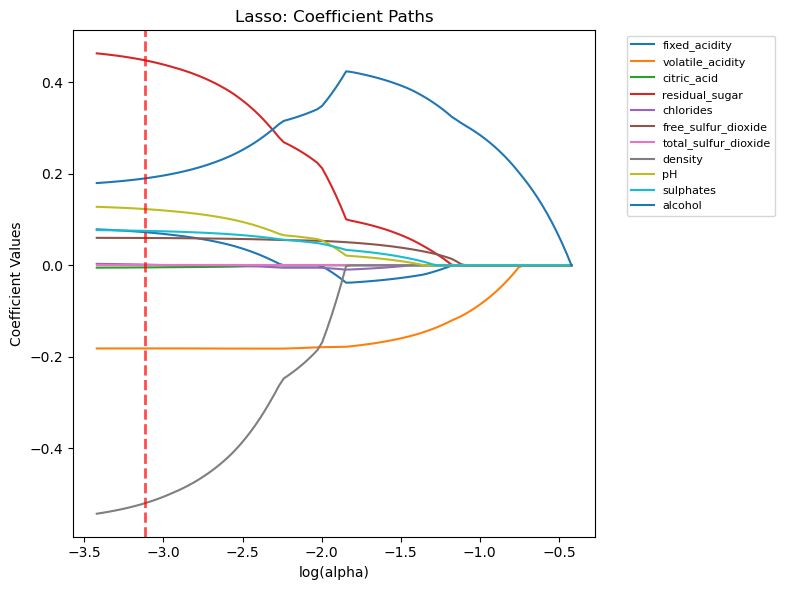

In [64]:
plt.figure(figsize=(8, 6))
feature_names = X_train.columns
coef_paths = []
for alpha in alphas:
    lasso_temp = ElasticNet(l1_ratio=1, alpha=alpha, random_state=1031, max_iter=2000)
    lasso_temp.fit(X_train_scaled, y_train)
    coef_paths.append(lasso_temp.coef_)
coef_paths = np.array(coef_paths)
# Plot of coefficient paths
for i, feature in enumerate(feature_names):
    plt.plot(np.log10(alphas), coef_paths[:, i], label=feature, linewidth=1.5)    
plt.axvline(x=np.log10(best_alpha), color='red', linestyle='--', alpha=0.7, linewidth=2)
plt.xlabel('log(alpha)')
plt.ylabel('Coefficient Values')
plt.title('Lasso: Coefficient Paths')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()